In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import time

In [13]:
#Load MNIST
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X,y=mnist.data, mnist.target

In [14]:
print(f"Shape: {X.shape}")
print(f"Classes: {np.unique(y)}")

Shape: (70000, 784)
Classes: ['0' '1' '2' '3' '4' '5' '6' '7' '8' '9']


In [15]:
#Train_test_split
X_train, X_test = X[:60000], X[60000:]
y_train, y_test = y[:60000], y[60000:]

In [16]:
#Standardize
#PCA is sensitive to scale
scaler = StandardScaler()
x_train_scaled=scaler.fit_transform(X_train)
x_test_scaled=scaler.transform(X_test)

In [17]:
# Find how many components explain 95% variance
pca_full=PCA()
pca_full.fit(x_train_scaled)

PCA()

In [18]:
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
print(f"\nComponents needed for 95% variance: {n_components_95}")


Components needed for 95% variance: 331


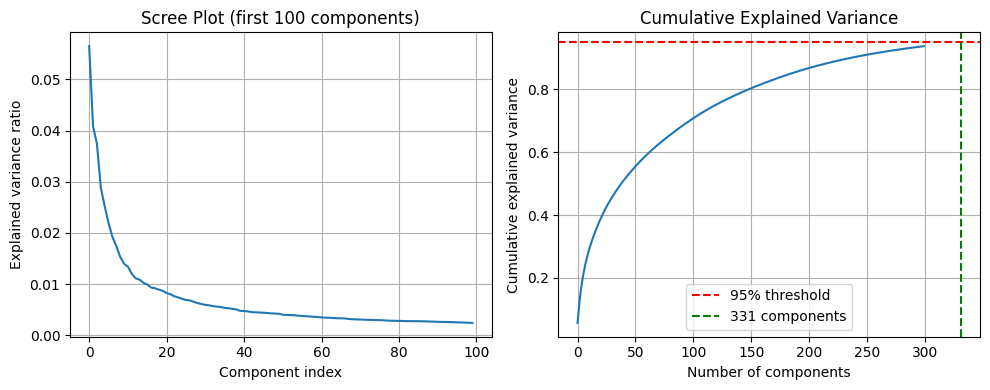

In [19]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(pca_full.explained_variance_ratio_[:100])
plt.xlabel("Component index")
plt.ylabel("Explained variance ratio")
plt.title("Scree Plot (first 100 components)")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(cumulative_variance[:300])
plt.axhline(0.95, color='red', linestyle='--', label='95% threshold')
plt.axvline(n_components_95, color='green', linestyle='--', label=f'{n_components_95} components')
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.title("Cumulative Explained Variance")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


Apply PCA  with 95% variance retrained

In [22]:
# Apply PCA with 95% variance retained
pca = PCA(n_components=n_components_95)
x_train_pca = pca.fit_transform(x_train_scaled)
x_test_pca  = pca.transform(x_test_scaled)

In [23]:
print(f"\nOriginal shape : {x_train_scaled.shape}")
print(f"Reduced shape  : {x_train_pca.shape}")


Original shape : (60000, 784)
Reduced shape  : (60000, 331)


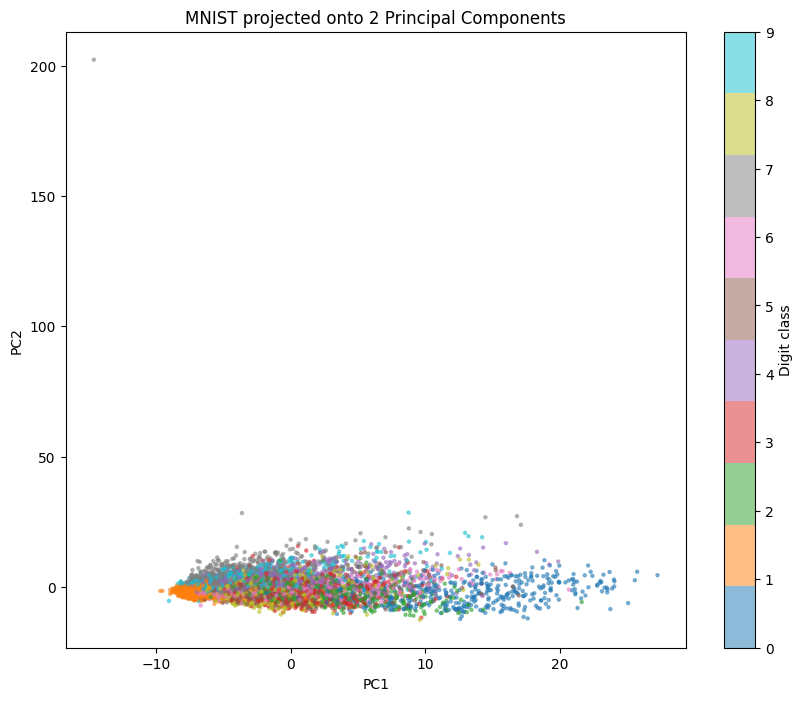

In [25]:
# Visualize in 2D using only 2 coponents
pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(x_train_scaled[:5000])
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1],
                      c=y_train[:5000].astype(int),
                      cmap='tab10', alpha=0.5, s=5)
plt.colorbar(scatter, label='Digit class')
plt.title("MNIST projected onto 2 Principal Components")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

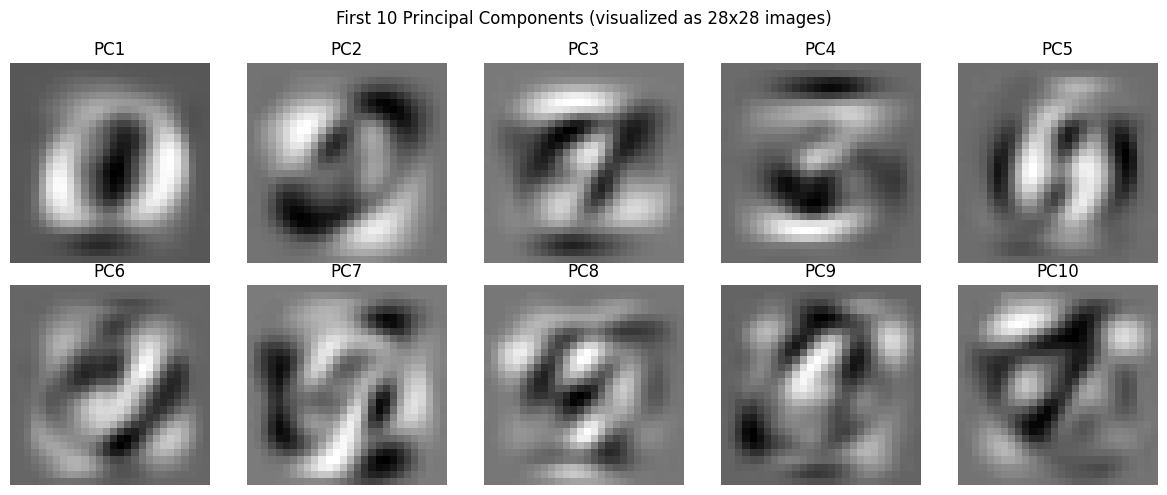

In [26]:
# Visualize what PCA components look like (eigenfaces)
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    component_image = pca.components_[i].reshape(28, 28)
    ax.imshow(component_image, cmap='gray')
    ax.set_title(f"PC{i+1}")
    ax.axis('off')
plt.suptitle("First 10 Principal Components (visualized as 28x28 images)")
plt.tight_layout()
plt.show()

In [29]:
#Reconstruction — compress then rebuild
# Take one sample digit, compress with PCA, reconstruct back
sample = x_train_scaled[0].reshape(1, -1)
compressed   = pca.transform(sample)
reconstructed = pca.inverse_transform(compressed)


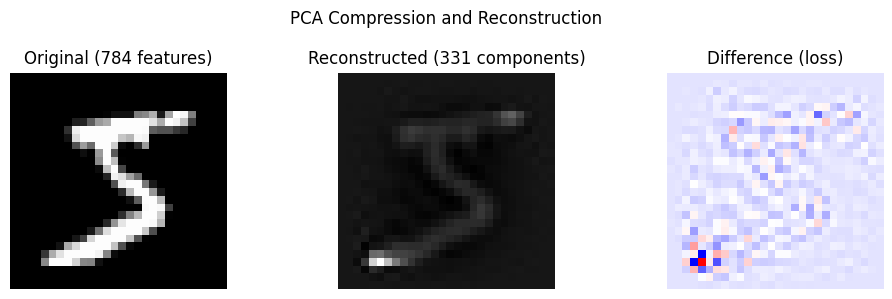

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(10, 3))

axes[0].imshow(X_train[0].reshape(28, 28), cmap='gray')
axes[0].set_title("Original (784 features)")
axes[0].axis('off')

axes[1].imshow(reconstructed.reshape(28, 28), cmap='gray')
axes[1].set_title(f"Reconstructed ({n_components_95} components)")
axes[1].axis('off')

axes[2].imshow((x_train_scaled[0] - reconstructed[0]).reshape(28, 28), cmap='bwr')
axes[2].set_title("Difference (loss)")
axes[2].axis('off')

plt.suptitle("PCA Compression and Reconstruction")
plt.tight_layout()
plt.show()


In [32]:
#Compare classifier speed: with vs without PCA Without PCA
clf_full = LogisticRegression(max_iter=300)
t0 = time.time()
clf_full.fit(x_train_scaled, y_train)
t_full = time.time() - t0
acc_full = accuracy_score(y_test, clf_full.predict(x_test_scaled))


In [37]:
# With PCA
clf_pca = LogisticRegression(max_iter=300)
t0 = time.time()
clf_pca.fit(x_train_pca, y_train)
t_pca = time.time() - t0
acc_pca = accuracy_score(y_test, clf_pca.predict(x_test_pca))

In [38]:
print("\n── Results ──────────────────────────────")
print(f"Without PCA → Accuracy: {acc_full:.4f}  |  Time: {t_full:.1f}s  |  Features: 784")
print(f"With PCA    → Accuracy: {acc_pca:.4f}  |  Time: {t_pca:.1f}s  |  Features: {n_components_95}")
print(f"\nSpeedup: {t_full/t_pca:.1f}x faster with PCA")
print(f"Accuracy drop: {(acc_full - acc_pca)*100:.2f}%")


── Results ──────────────────────────────
Without PCA → Accuracy: 0.9217  |  Time: 98.8s  |  Features: 784
With PCA    → Accuracy: 0.9266  |  Time: 49.5s  |  Features: 331

Speedup: 2.0x faster with PCA
Accuracy drop: -0.49%
